# Money Back V0.2：T5 严格验证

本笔记是 `v0.2-strict-research` 的可重复审计入口。它只读取研究内核生成的有版本结果，不在笔记中重新定义策略。

结论不构成投资建议或实盘授权。

## tl;dr

- **决策：STOP。** 免费数据未通过时点一致 ETF 名册、可信成交额和独立第二行情源三项闸门。
- V0.1 冻结回归仍为 **3.23 倍**，最大回撤 **-21.3%**。
- V0.2 固定池 T5 的滚动三年中位数约 **2.76 倍**，最大回撤 **-28.1%**。
- 波动控制版最大回撤降至 **-24.2%**，但滚动三年中位数只有 **2.31 倍**，仍未达到 4 倍目标。

## Context & Methods

### Key Assumptions

- 资产边界：境内股票型宽基、行业和主题 ETF，加现金；跨境 ETF 只保留在 V0.1 重建回归中。
- 信号：复权收盘；基准执行：次日 OHLC4/TWAP 代理、单边 10bp。
- 压力执行：信号延迟到第二个开盘、单边 20bp。
- 固定池性能从至少两只境内 ETF 已上市 120 个交易日时开始。
- 只有数据闸门和性能门槛同时通过，才允许进入 12 周纸面跟踪。

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd()
OUTPUT_DIR = ROOT / "outputs" / "v0_2"
summary = pd.read_csv(OUTPUT_DIR / "strategy_summary.csv")
rolling = pd.read_csv(OUTPUT_DIR / "rolling_3y_multiples.csv", parse_dates=["date"])
sources = pd.read_csv(OUTPUT_DIR / "source_manifest.csv")
issues = pd.read_csv(OUTPUT_DIR / "data_quality_issues.csv")
decision = json.loads((OUTPUT_DIR / "decision.json").read_text(encoding="utf-8"))

## Data

In [2]:
display(Markdown(f"**数据闸门：{decision['data_gate']['status']}。** 当前结果只能标记为固定池探索。"))
display(sources.groupby(["label", "series"], as_index=False).agg(
    first_date=("first_date", "min"), last_date=("last_date", "max"), rows=("rows", "max")
))
display(issues[["code", "severity", "message", "symbol", "date"]].head(20))

**数据闸门：FAIL。** 当前结果只能标记为固定池探索。

,label,series,first_date,last_date,rows
0,159206,adjusted,2025-03-14,2026-07-17,327
1,159206,raw,2025-03-14,2026-07-17,327
2,159516,adjusted,2023-07-27,2026-07-17,720
3,159516,raw,2023-07-27,2026-07-17,720
4,513120,adjusted,2022-07-12,2026-07-17,974
5,513120,raw,2022-07-12,2026-07-17,974
6,515880,adjusted,2019-09-06,2026-07-17,1661
7,515880,raw,2019-09-06,2026-07-17,1661
8,561380,adjusted,2024-12-23,2026-07-17,379
9,561380,raw,2024-12-23,2026-07-17,379


,code,severity,message,symbol,date
0,survivorship_coverage_missing,critical,Free master does not prove coverage of deliste...,NaN,NaN
1,history_starts_too_late,critical,Master coverage begins after 2016-01-01,NaN,NaN
2,adjustment_factor_jump,medium,Adjustment factor changed by 100.00%,159516.0,2026-03-30
3,adjustment_factor_jump,medium,Adjustment factor changed by 99.90%,159516.0,2026-07-10
4,adjustment_factor_jump,medium,Adjustment factor changed by 199.81%,515880.0,2026-02-03
5,adjustment_factor_jump,medium,Adjustment factor changed by 99.87%,515880.0,2026-07-06
6,adjustment_factor_jump,medium,Adjustment factor changed by 150.05%,561380.0,2026-06-25
7,turnover_amount_missing,critical,No auditable turnover amount matrix,NaN,NaN
8,dual_source_coverage_incomplete,critical,Not every ETF has a second independently sourc...,NaN,NaN


## Results

,strategy_id,ending_equity,cagr,max_drawdown,median_multiple,p25_multiple,worst_multiple,trade_days_per_year
0,t5_v0_2_baseline,3.151848,0.342987,-0.281486,2.755574,2.068552,1.524086,22.348624
20,t5_volatility_control_30,2.817826,0.304891,-0.242195,2.314790,1.755353,1.350424,32.110092
22,challenger_a_dual_momentum,2.077483,0.206617,-0.389926,1.741006,1.543884,1.113693,10.788991
24,challenger_b_vol_adjusted_trend,2.045061,0.201751,-0.246426,1.740914,1.619000,1.267886,17.211009


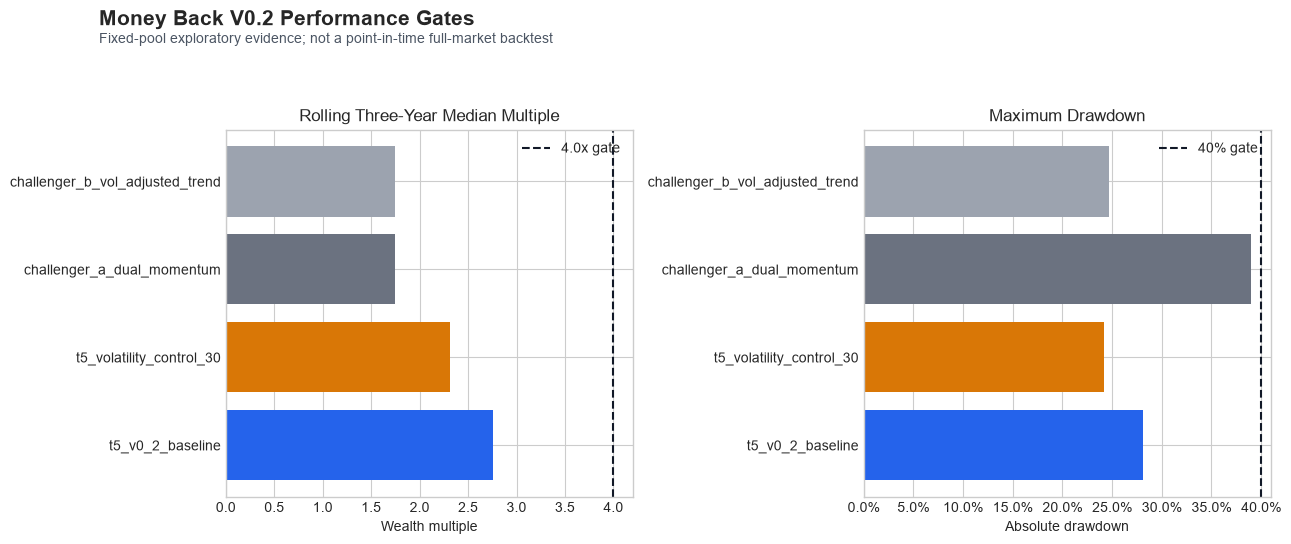

In [3]:
focus_ids = [
    "t5_v0_2_baseline",
    "t5_volatility_control_30",
    "challenger_a_dual_momentum",
    "challenger_b_vol_adjusted_trend",
]
focus = summary[(summary.strategy_id.isin(focus_ids)) & (summary.scenario == "base")].copy()
display(focus[["strategy_id", "ending_equity", "cagr", "max_drawdown", "median_multiple", "p25_multiple", "worst_multiple", "trade_days_per_year"]])

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors = ["#2563EB", "#D97706", "#6B7280", "#9CA3AF"]
axes[0].barh(focus.strategy_id, focus.median_multiple, color=colors)
axes[0].axvline(4.0, color="#111827", linestyle="--", linewidth=1.5, label="4.0x gate")
axes[0].set_title("Rolling Three-Year Median Multiple")
axes[0].set_xlabel("Wealth multiple")
axes[0].legend(frameon=False)
axes[1].barh(focus.strategy_id, focus.max_drawdown.abs(), color=colors)
axes[1].axvline(0.40, color="#111827", linestyle="--", linewidth=1.5, label="40% gate")
axes[1].set_title("Maximum Drawdown")
axes[1].set_xlabel("Absolute drawdown")
axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[1].legend(frameon=False)
fig.suptitle("Money Back V0.2 Performance Gates", x=0.08, ha="left", fontsize=15, weight="bold")
fig.text(0.08, 0.92, "Fixed-pool exploratory evidence; not a point-in-time full-market backtest", color="#4B5563")
fig.tight_layout(rect=[0, 0, 1, 0.89])
comparison_path = OUTPUT_DIR / "performance_gate_comparison.png"
fig.savefig(comparison_path, dpi=180, bbox_inches="tight")
plt.show()

## Limitations, uncertainty, and robustness

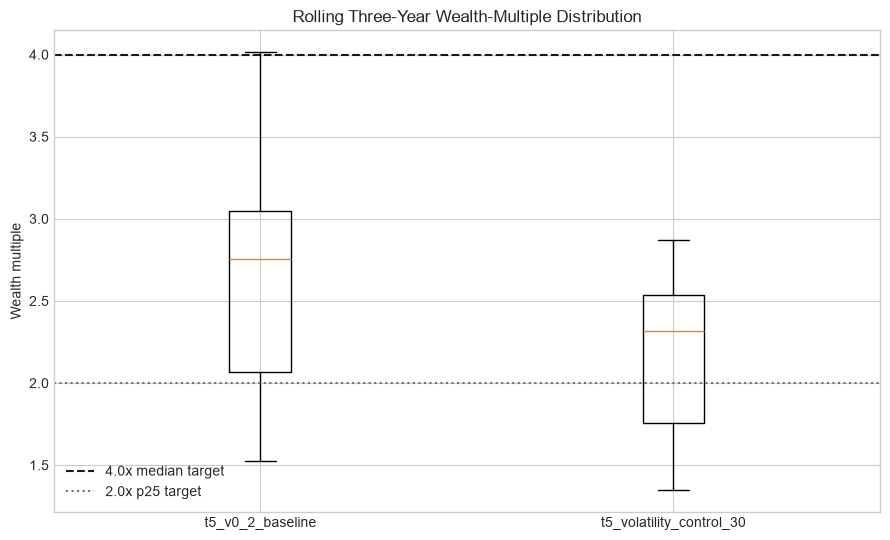

The distributions are descriptive only. The six-product fixed pool omits historical delistings and most ETFs that existed before these products launched.

In [4]:
selected = rolling[(rolling.scenario == "base") & rolling.strategy_id.isin(["t5_v0_2_baseline", "t5_volatility_control_30"])]
groups = [group.multiple.to_numpy() for _, group in selected.groupby("strategy_id")]
labels = [name for name, _ in selected.groupby("strategy_id")]
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.boxplot(groups, tick_labels=labels, showfliers=False)
ax.axhline(4.0, color="#111827", linestyle="--", linewidth=1.5, label="4.0x median target")
ax.axhline(2.0, color="#6B7280", linestyle=":", linewidth=1.5, label="2.0x p25 target")
ax.set_title("Rolling Three-Year Wealth-Multiple Distribution")
ax.set_ylabel("Wealth multiple")
ax.legend(frameon=False)
fig.tight_layout()
distribution_path = OUTPUT_DIR / "rolling_3y_distribution.png"
fig.savefig(distribution_path, dpi=180, bbox_inches="tight")
plt.show()

display(Markdown(
    "The distributions are descriptive only. The six-product fixed pool omits historical delistings and most ETFs that existed before these products launched."
))

## Takeaways

1. V0.1 已被新内核精确复现，重构没有改写已冻结结论。
2. 严格数据闸门未通过，所以任何收益数字都不能升级为全市场证据。
3. 在可运行的固定池范围内，T5 与波动控制版都未达到滚动三年中位 4 倍。
4. 波动控制降低了回撤，却没有创造足够的收益补偿；这正说明不能只围绕止损继续调参。
5. 当前正确动作是停止策略扩搜，先解决历史退市名册、成交额和第二行情源。

## Further questions

- 能否以免费方式获得 2013 年以来包含退市状态的 ETF 主数据？
- 第二行情源能否在复权因子、停牌和异常跳变上与当前来源独立核对？